# Modelo Mono-modal: DSTFS Adaptado para Tarea Única

Este cuaderno implementa el entrenamiento y la evaluación del **DSTFS-adapted** (Deep Soft Threshold Feature Separation) adaptado exclusivamente para la tarea de regresión temporal en la disipación de huellas térmicas sobre superficies.

Incorpora el mecanismo de activación de **Umbral Suave PReLU (SPRelu)** para mitigar el ruido débil e inestable residual, y utiliza la función de pérdida robusta **SqrtScaledMSELoss** para amplificar el gradiente en las etapas iniciales de decaimiento rápido.

In [1]:
import sys
import random
from pathlib import Path

# Añadir el directorio raíz al path de Python para permitir importaciones correctas
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

from src.models.dstfs import ThermalDepartureTimeNet
from src.loaders.dstfs_loader import ThermalTraceDataset
from src.utils import SqrtScaledMSELoss, eval_dstfs_metrics, build_subject_split_plan, subject_summary, plot_learning_curves, plot_prediction_calibration, plot_error_by_time_window

### 1. Semilla Global y Reproducibilidad

In [2]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

### 2. Configuración General (Hiperparámetros)

In [3]:
CONFIG = {
    "epochs": 120,
    "patience": 15,
    "min_delta": 1.0,
    "batch_size": 16,
    "lr": 0.0005,          # SGD lr inicial de 0.0005
    "weight_decay": 0.0005, # DSTFS: Regularización L2 de 0.0005
    "momentum": 0.9,       # SGD Momentum de 0.9
    "min_time_s": 0.0,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "time_scale": 30.0,
}

### 3. Instanciación del Dataset y Dataloaders

In [4]:
dev = CONFIG["device"]

# Los datasets esperan las rutas relativas al directorio principal
train_ds_full = ThermalTraceDataset(metadata_csv="../processed_data/metadata_train.csv", is_train=True, min_time_s=CONFIG["min_time_s"], time_scale=CONFIG["time_scale"])
val_ds_full = ThermalTraceDataset(metadata_csv="../processed_data/metadata_train.csv", is_train=False, min_time_s=CONFIG["min_time_s"], time_scale=CONFIG["time_scale"])

# Adaptamos la ruta raíz de los datasets para que apunte al directorio correcto en notebooks
train_ds_full.root = Path("../processed_data")
val_ds_full.root = Path("../processed_data")

df = train_ds_full.df

print("Resumen de sujetos en metadata:")
print(subject_summary(df))

plan = build_subject_split_plan(
    df,
    n_splits=5,
    seed=42,
    test_subjects=["tania"],
    reserve_incomplete_for_test=True,
)

print("\nPlan de partición:")
print(f"Sujetos de Test ({plan.num_test_subjects}): {plan.test_subjects} (Muestras: {plan.num_test_samples})")
print(f"Sujetos de Train/Val ({plan.num_trainval_subjects}): {plan.trainval_subjects} (Muestras: {plan.num_trainval_samples})")
print(f"Número de folds para CV: {len(plan.folds)}")
for f in plan.folds:
    print(f"  Fold {f.fold}: Train subjects {f.train_subjects} ({len(f.train_indices)} muestras), Val subjects {f.val_subjects} ({len(f.val_indices)} muestras)")

Resumen de sujetos en metadata:
        name  n_sequences  n_samples      surface  gender  is_complete
0     alonso            3        141        glass    male        False
1     angelo            6        281  glass, wood    male         True
2    eduardo            1         47         wood    male        False
3    esteban            6        276  glass, wood    male         True
4   fabricio            6        278  glass, wood    male         True
5    johamin            2         93         wood    male        False
6  juandiego            6        280  glass, wood    male         True
7     matias            6        282  glass, wood    male         True
8     renato            3        141         wood    male        False
9      tania            6        278  glass, wood  female         True

Plan de partición:
Sujetos de Test (5): ['alonso', 'eduardo', 'johamin', 'renato', 'tania'] (Muestras: 700)
Sujetos de Train/Val (5): ['angelo', 'esteban', 'fabricio', 'juandiego', 'mati

### 4. Inicialización del Modelo, Pérdida y Optimización

In [5]:
model = ThermalDepartureTimeNet().to(dev)
print(f"Parámetros totales de DSTFS-adapted: {sum(p.numel() for p in model.parameters()):,}")

Parámetros totales de DSTFS-adapted: 11,515,811


### 5. Ciclo de Entrenamiento e Impresión de Métricas Unificadas

In [6]:
set_seed(42)

fold_metrics = []
histories = []

print("=" * 60)
print("FASE A: VALIDACIÓN CRUZADA POR SUJETO (BASELINE)")
print("=" * 60)

for fold in plan.folds:
    print(f"\nEntrenando Fold {fold.fold}/{len(plan.folds)} <<<")
    print(f"Train subjects: {fold.train_subjects}")
    print(f"Val subjects: {fold.val_subjects}")
    
    train_loader = DataLoader(Subset(train_ds_full, fold.train_indices), batch_size=CONFIG["batch_size"], shuffle=True, drop_last=True)
    val_loader = DataLoader(Subset(val_ds_full, fold.val_indices), batch_size=CONFIG["batch_size"])
    train_eval_loader = DataLoader(Subset(train_ds_full, fold.train_indices), batch_size=CONFIG["batch_size"])
    
    model = ThermalDepartureTimeNet().to(dev)
    crit = SqrtScaledMSELoss(scale=None)
    opt = torch.optim.SGD(model.parameters(), lr=CONFIG["lr"], momentum=CONFIG["momentum"], weight_decay=CONFIG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[30, 60, 80], gamma=0.8)
    
    best_val_mae = float("inf")
    no_imp = 0
    best_metrics = None
    history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}
    
    for ep in range(1, CONFIG["epochs"] + 1):
        model.train()
        train_loss, n = 0.0, 0
        for x, y in train_loader:
            x, y = x.to(dev), y.to(dev)
            opt.zero_grad(set_to_none=True)
            loss = crit(model(x), y)
            loss.backward()
            opt.step()
            train_loss += loss.item() * x.size(0)
            n += x.size(0)
            
        scheduler.step()
        
        model.eval()
        val_loss, val_n = 0.0, 0
        with torch.no_grad():
            for val_x, val_y in val_loader:
                val_x, val_y = val_x.to(dev), val_y.to(dev)
                loss = crit(model(val_x), val_y)
                val_loss += loss.item() * val_x.size(0)
                val_n += val_x.size(0)
        val_loss /= val_n
        
        val_m = eval_dstfs_metrics(model, val_loader, dev, scale=CONFIG["time_scale"])
        train_m = eval_dstfs_metrics(model, train_eval_loader, dev, scale=CONFIG["time_scale"])
        
        v_mae = val_m["mae"]
        is_best = v_mae < best_val_mae - CONFIG["min_delta"]
        if is_best:
            best_val_mae, no_imp = v_mae, 0
            best_metrics = val_m
            torch.save(model.state_dict(), f"../DSTFS_adapted_fold{fold.fold}.pt")
        else:
            no_imp += 1
            
        history["train_loss"].append(train_loss / n)
        history["val_loss"].append(val_loss)
        history["train_mae"].append(train_m["mae"])
        history["val_mae"].append(v_mae)
        
        if no_imp >= CONFIG["patience"]:
            break
            
    print(f"Fold {fold.fold} finalizado. Mejor Val MAE: {best_val_mae:.2f}s")
    fold_metrics.append(best_metrics)
    histories.append(history)

# Calcular promedio y desviación estándar de validación de los folds
df_folds = pd.DataFrame(fold_metrics)
cv_mean = df_folds.mean().to_dict()
cv_std = df_folds.std().to_dict()

print("\n" + "=" * 60)
print("PROMEDIO DE MÉTRICAS CV (VALIDACIÓN CRUZADA)")
print("=" * 60)
for k in cv_mean.keys():
    print(f"{str(k).upper()}: {cv_mean[k]:.2f} ± {cv_std[k]:.2f}")

print("\n" + "=" * 60)
print("FASE A: ENTRENAMIENTO FINAL EN ALL TRAINVAL Y EVAL EN TEST")
print("=" * 60)

trainval_loader = DataLoader(Subset(train_ds_full, plan.trainval_indices), batch_size=CONFIG["batch_size"], shuffle=True, drop_last=True)
test_loader = DataLoader(Subset(val_ds_full, plan.test_indices), batch_size=CONFIG["batch_size"])

model_final = ThermalDepartureTimeNet().to(dev)
crit = SqrtScaledMSELoss(scale=None)
opt = torch.optim.SGD(model_final.parameters(), lr=CONFIG["lr"], momentum=CONFIG["momentum"], weight_decay=CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[30, 60, 80], gamma=0.8)

# Entrenar por el promedio óptimo de épocas de los folds
avg_epochs = int(np.mean([len(h["train_loss"]) - CONFIG["patience"] for h in histories]))
avg_epochs = max(10, avg_epochs)
print(f"Entrenando modelo final por {avg_epochs} épocas...")

for ep in range(1, avg_epochs + 1):
    model_final.train()
    train_loss, n = 0.0, 0
    for x, y in trainval_loader:
        x, y = x.to(dev), y.to(dev)
        opt.zero_grad(set_to_none=True)
        loss = crit(model_final(x), y)
        loss.backward()
        opt.step()
        train_loss += loss.item() * x.size(0)
        n += x.size(0)
    scheduler.step()

torch.save(model_final.state_dict(), "../DSTFS_adapted_final.pt")
final_metrics = eval_dstfs_metrics(model_final, test_loader, dev, scale=CONFIG["time_scale"])
print(f"Modelo Final evaluado en Test Set (Held-out).")
print(f"MAE: {final_metrics['mae']:.2f}s | RMSE: {final_metrics['rmse']:.2f}s | R2: {final_metrics['r2']:.4f}")
print(f"MAPE: {final_metrics['mape']:.2f}% | Acc60: {final_metrics['acc60']:.2f}% | Acc120: {final_metrics['acc120']:.2f}%")

FASE A: VALIDACIÓN CRUZADA POR SUJETO (BASELINE)

Entrenando Fold 1/5 <<<
Train subjects: ['angelo', 'esteban', 'fabricio', 'juandiego']
Val subjects: ['matias']
Fold 1 finalizado. Mejor Val MAE: 34.81s

Entrenando Fold 2/5 <<<
Train subjects: ['angelo', 'esteban', 'juandiego', 'matias']
Val subjects: ['fabricio']
Fold 2 finalizado. Mejor Val MAE: 30.86s

Entrenando Fold 3/5 <<<
Train subjects: ['angelo', 'esteban', 'fabricio', 'matias']
Val subjects: ['juandiego']
Fold 3 finalizado. Mejor Val MAE: 28.76s

Entrenando Fold 4/5 <<<
Train subjects: ['angelo', 'fabricio', 'juandiego', 'matias']
Val subjects: ['esteban']
Fold 4 finalizado. Mejor Val MAE: 30.03s

Entrenando Fold 5/5 <<<
Train subjects: ['esteban', 'fabricio', 'juandiego', 'matias']
Val subjects: ['angelo']
Fold 5 finalizado. Mejor Val MAE: 49.74s

PROMEDIO DE MÉTRICAS CV (VALIDACIÓN CRUZADA)
MAE: 34.84 ± 8.63
RMSE: 52.50 ± 7.27
R2: 0.89 ± 0.03
MAPE: 44.66 ± 20.60
ACC60: 80.84 ± 7.29
ACC120: 95.42 ± 0.86

FASE A: ENTRENAMIENT

### 6. Visualización de Resultados Experimentales y Curvas de Aprendizaje

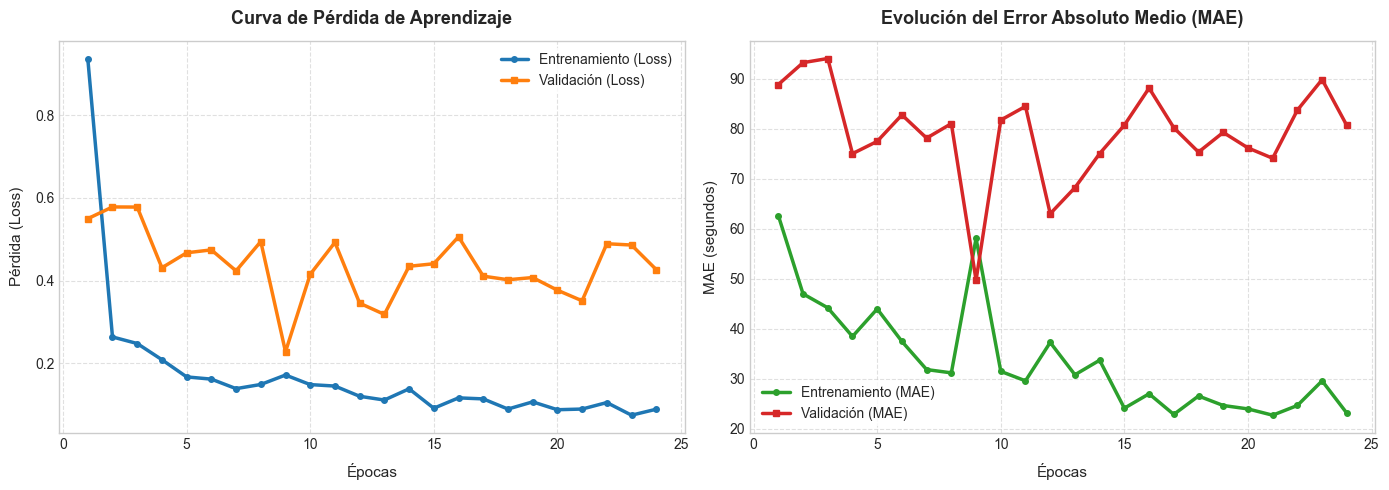

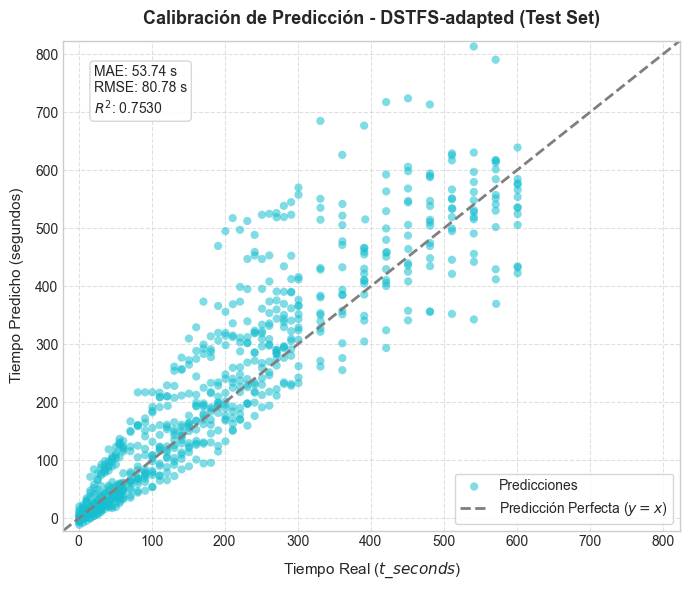

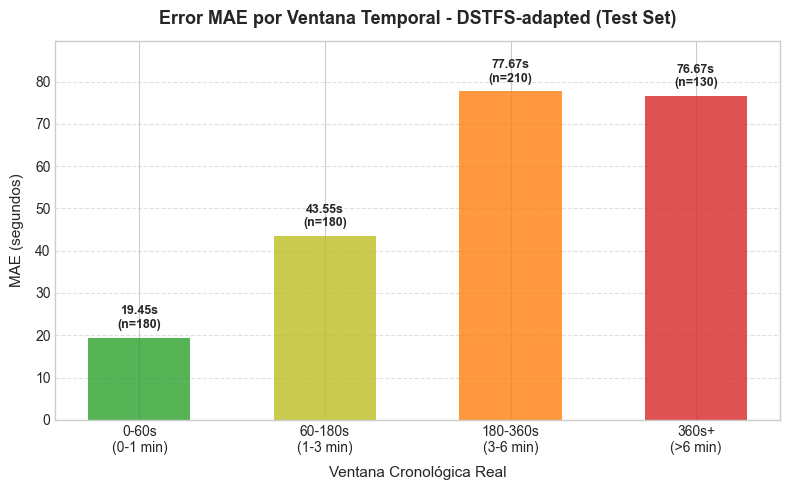

In [7]:
import numpy as np

# Cargar el modelo final entrenado para graficar y evaluar predicciones en Test
model_final.load_state_dict(torch.load("../DSTFS_adapted_final.pt"))
model_final.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(dev), y.to(dev)
        pred = model_final(x)
        # Desescalar predicciones y reales
        y_true.extend((y.cpu().numpy() * CONFIG["time_scale"]).tolist())
        y_pred.extend((pred.cpu().numpy() * CONFIG["time_scale"]).tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 1. Curvas de aprendizaje del último fold de validación cruzada
plot_learning_curves(histories[-1])

# 2. Gráfico de Calibración de Predicciones en el Test Set
plot_prediction_calibration(y_true, y_pred, model_name="DSTFS-adapted (Test Set)")

# 3. Distribución del error por ventana temporal en el Test Set
plot_error_by_time_window(y_true, y_pred, model_name="DSTFS-adapted (Test Set)")